# plan5 public v3 — res2+fixedop+mae_raw+size_ind (bi3×3seed)

Members listed in `members.json` (unique `best_epoch` per run).

**Scoring:** for each member, daily cross-sectional z-score; then equal-weight average across members.

Do **not** average raw scores then z-score.

- M3 (`silu_res2` / `fixedop`): `pack=full2` + `feat_norm=post_pack`
- MAE (`mae` / `mae_size_ind`): `pack=none` + `feat_norm=per_day`（共用特征；size_ind 仅训练标签不同）

**IO:** monthly chunks — one `load_cloud_range_bars` per month → shared `build_raw_day_panel` → MAE `normalize_day_panel` → clear cache (carry lookback only).


kept=32 dropped=4 missing_runs=[]
  model_silu_res2_seed42_best_rankic_bi_ep30.json
  model_silu_res2_seed42_best_rankic_bi_ir_ep39.json
  model_silu_res2_seed42_best_bi_sharpe_ep40.json
  model_silu_res2_seed7_best_bi_sharpe_ep32.json
  model_silu_res2_seed7_best_rankic_bi_ep35.json
  model_silu_res2_seed7_best_rankic_bi_ir_ep40.json
  model_silu_res2_seed123_best_rankic_bi_ep23.json
  model_silu_res2_seed123_best_bi_sharpe_ep24.json
  model_silu_res2_seed123_best_rankic_bi_ir_ep33.json
  model_fixedop_seed42_best_rankic_bi_ep26.json
  model_fixedop_seed42_best_bi_sharpe_ep31.json
  model_fixedop_seed42_best_rankic_bi_ir_ep39.json
  model_fixedop_seed7_best_rankic_bi_ep22.json
  model_fixedop_seed7_best_rankic_bi_ir_ep36.json
  model_fixedop_seed7_best_bi_sharpe_ep38.json
  model_fixedop_seed123_best_bi_sharpe_ep31.json
  model_fixedop_seed123_best_rankic_bi_ep40.json
  model_mae_seed42_best_rankic_bi_ep33.json
  model_mae_seed42_best_rankic_bi_ir_ep36.json
  model_mae_seed7_best_bi_s

/opt/pyenv/versions/3.11.8/lib/python3.11/site-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


loaded 32 member(s) (m3=17, mae_like=15) from 32 json file(s)
[timing] cloud chunk 2023-12-29~2023-12-31 rows=287,280 elapsed=0.6s
[timing] cloud chunk 2024-01-01~2024-01-31 rows=6,332,400 elapsed=2.5s
[block] 2024-01 scored=22/22 fetch_days=23 rows=6,619,680 io=18.3s score=214.8s
[timing] cloud chunk 2024-02-01~2024-02-29 rows=4,325,520 elapsed=2.3s
[block] 2024-02 scored=15/15 fetch_days=15 rows=4,325,520 io=11.4s score=144.7s
[timing] cloud chunk 2024-03-01~2024-03-29 rows=6,054,960 elapsed=3.0s
[block] 2024-03 scored=21/21 fetch_days=21 rows=6,054,960 io=13.1s score=194.8s
[timing] cloud chunk 2024-04-01~2024-04-30 rows=5,776,080 elapsed=2.6s
[block] 2024-04 scored=20/20 fetch_days=20 rows=5,776,080 io=12.5s score=186.5s
[timing] cloud chunk 2024-05-06~2024-05-31 rows=5,771,760 elapsed=2.4s
[block] 2024-05 scored=20/20 fetch_days=20 rows=5,771,760 io=13.1s score=187.3s
[timing] cloud chunk 2024-06-03~2024-06-28 rows=5,481,120 elapsed=2.9s
[block] 2024-06 scored=19/19 fetch_days=19 

时段,IC
2024-01-15~2024-02-08,0.0368
2024-09-24~2024-10-08,0.0018

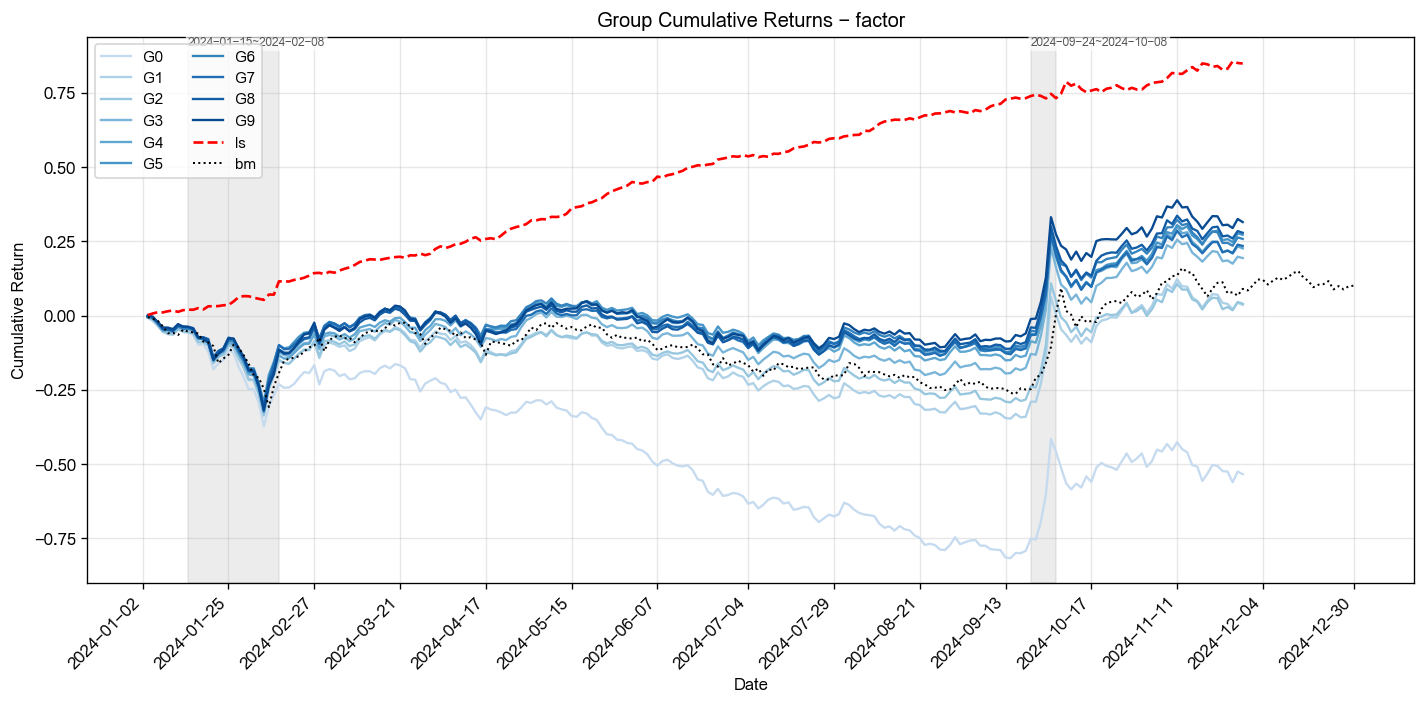
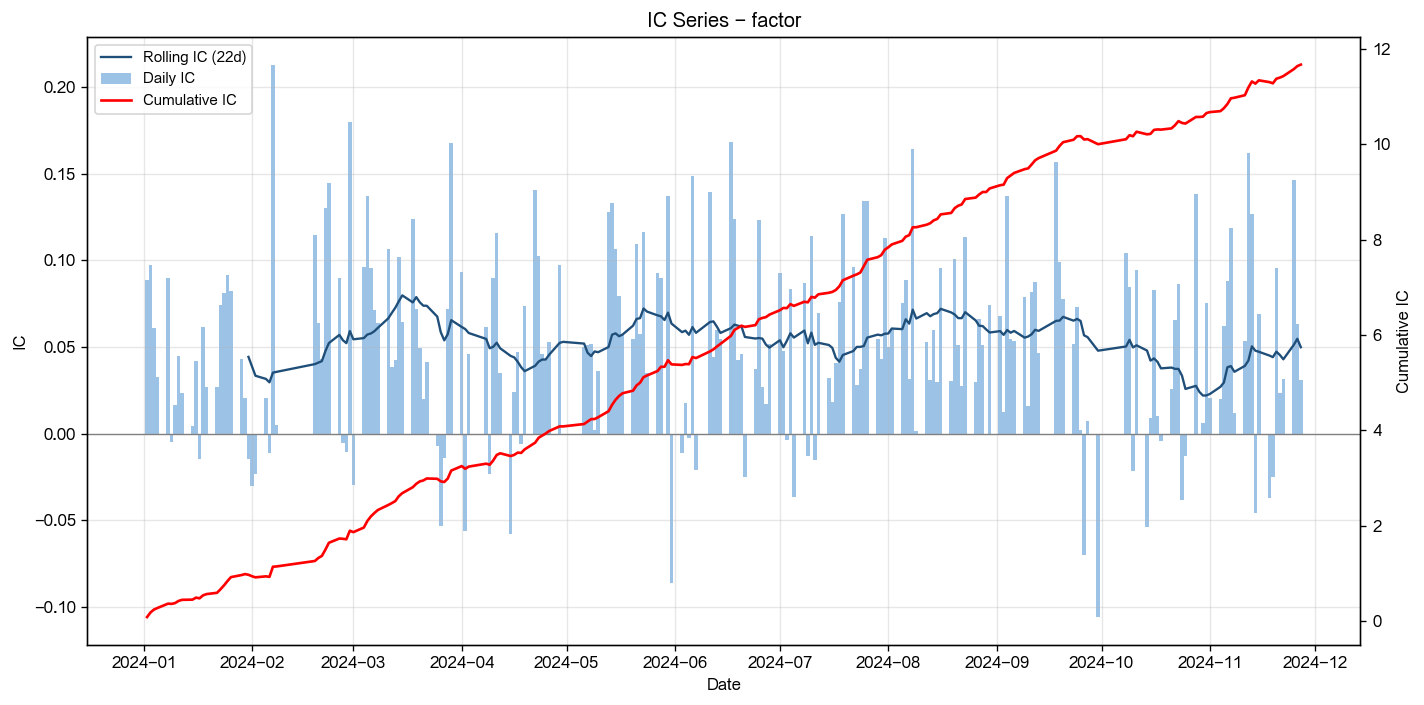
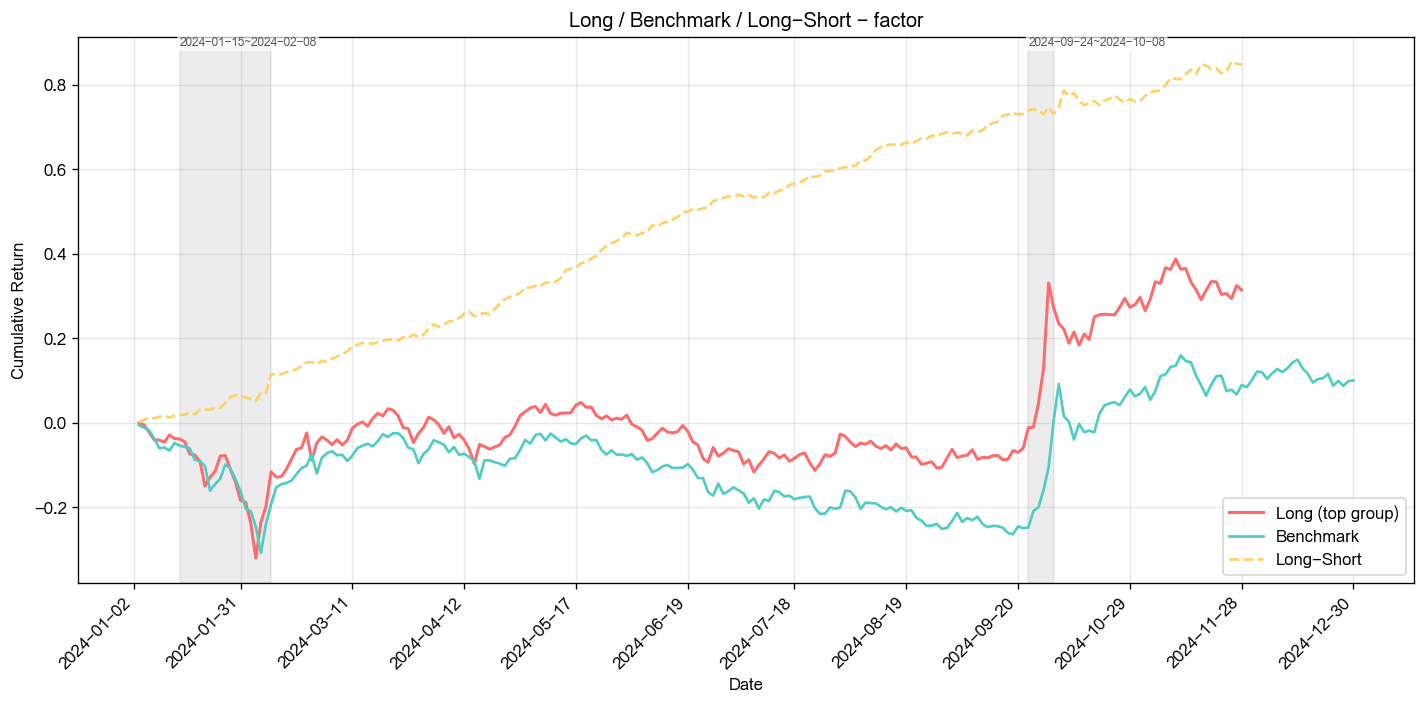
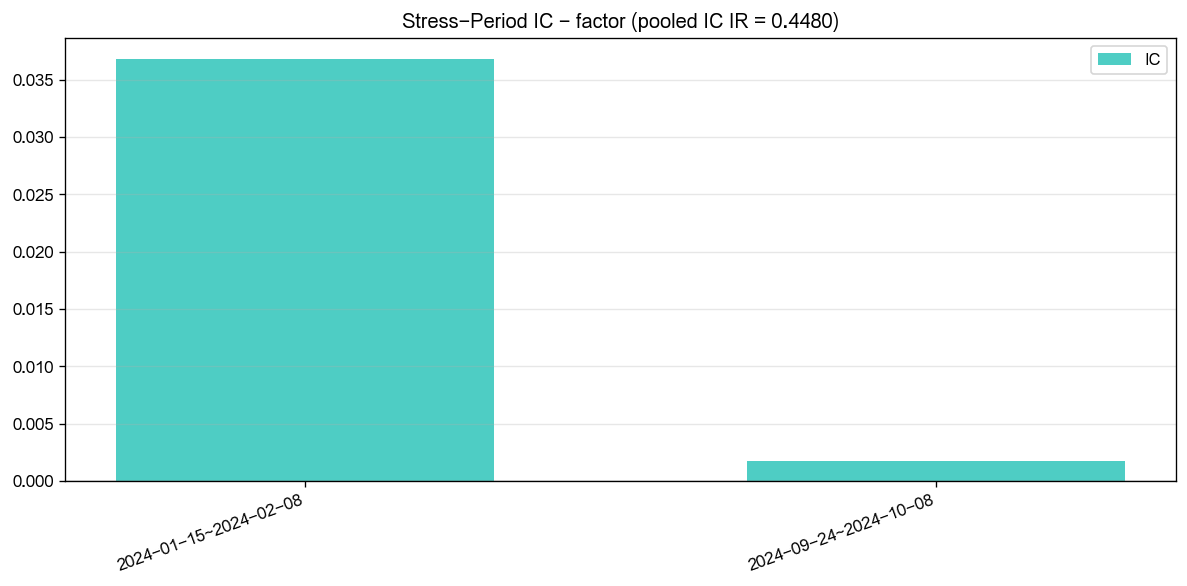
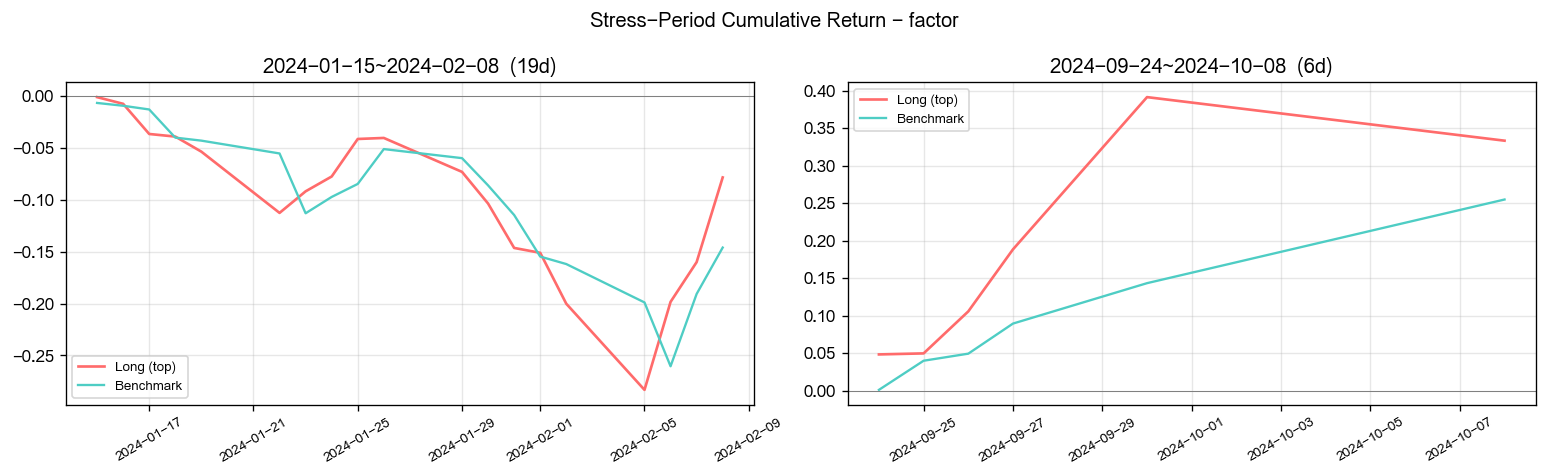

[2026-08-04 23:10:57] [warning  ] 未传入因子池，跳过因子池回归检验
[2026-08-04 23:10:57] [warning  ] 返回的Outputs实例(size=35131241) 大于 64K, 将不会被缓存
[2026-08-04 23:10:57] [info     ] bigalpha_eval.v4 运行完成 [27.448s].
{'raw_factor':              date instrument    factor
0      2024-01-02  000006.SZ  0.054835
1      2024-01-02  000012.SZ  1.742241
2      2024-01-02  000016.SZ -1.368131
3      2024-01-02  000019.SZ  1.371934
4      2024-01-02  000025.SZ -0.707274
...           ...        ...       ...
240736 2024-12-30  688766.SH -0.934342
240737 2024-12-30  688776.SH  0.156322
240738 2024-12-30  688779.SH  1.113013
240739 2024-12-30  688789.SH -0.495005
240740 2024-12-30  688798.SH -0.611653

[240741 rows x 3 columns], 'process_factor':              date instrument    factor
0      2024-01-02  000006.SZ  0.059331
1      2024-01-02  000012.SZ  0.606421
2      2024-01-02  000016.SZ -1.736482
3      2024-01-02  000019.SZ  0.837192
4      2024-01-02  000025.SZ -0.820601
...           ...        ...       ...
240

In [1]:
"""公榜推理入口：按 members.json 加载 kept ckpt，截面 z-score 后等权平均并评测。"""
import gc
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch

try:
    _HERE = Path(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    _HERE = Path(os.getcwd())
if str(_HERE) not in sys.path:
    sys.path.insert(0, str(_HERE))

import mae_train
import temporal_conv_train
from ensemble_infer import (
    ensemble_day_scores,
    is_mae_family,
    list_member_json_paths,
    load_ensemble_members,
    load_members_manifest,
)
from mae_train import (
    CloudDailyDataset as MaeDailyDataset,
    normalize_day_panel,
)
from temporal_conv_train import (
    CLOUD_TABLE,
    N_DAY as M3_N_DAY,
    CloudDailyDataset as M3DailyDataset,
    DayPanel,
    TradingCalendar,
    build_raw_day_panel,
    get_dai,
    load_cloud_range_bars,
    pool_instruments,
    valid_sample_days,
)


def _align_by_instruments(
    x: torch.Tensor,
    instruments: np.ndarray,
    common: np.ndarray,
) -> torch.Tensor:
    pos = {str(ins): j for j, ins in enumerate(instruments)}
    idx = np.array([pos[str(ins)] for ins in common], dtype=np.int64)
    return x[idx]


def _assert_raw_panel_shared() -> None:
    """两族共用原始面板的前提：log1p / pivot / 缺失过滤口径完全一致。"""
    checks = [
        ("FEATURE_COLS", list(temporal_conv_train.FEATURE_COLS), list(mae_train.FEATURE_COLS)),
        ("VOL_COLS", list(temporal_conv_train.VOL_COLS), list(mae_train.VOL_COLS)),
        ("bars_per_day", int(temporal_conv_train.T_DAY), int(mae_train.T_INTRADAY)),
        (
            "MISSING_BAR_FRAC",
            float(temporal_conv_train.MISSING_BAR_FRAC),
            float(mae_train.MISSING_BAR_FRAC),
        ),
    ]
    for name, m3_val, mae_val in checks:
        if m3_val != mae_val:
            raise RuntimeError(
                f"{name} diverged between m3/mae ({m3_val!r} vs {mae_val!r}); "
                "raw day panels can no longer be shared"
            )


def _month_blocks(sample_days: list[str]) -> list[tuple[str, list[str]]]:
    blocks: dict[str, list[str]] = {}
    for day in sample_days:
        blocks.setdefault(str(day)[:7], []).append(str(day))
    return [(m, blocks[m]) for m in sorted(blocks)]


def _needed_days(
    calendar: TradingCalendar,
    block_days: list[str],
    n_day: int,
) -> list[str]:
    """块内样本日 + M3 回看日，按日期升序。"""
    seen: set[str] = set()
    for day in block_days:
        win = calendar.window(day, n_day)
        if win is None:
            continue
        seen.update(win)
    return sorted(seen)


def _build_raw_panels(bars: pd.DataFrame, days: list[str]) -> dict[str, DayPanel]:
    out: dict[str, DayPanel] = {}
    if bars is None or bars.empty:
        return out
    want = set(days)
    key = pd.to_datetime(bars["date"]).dt.normalize().dt.strftime("%Y-%m-%d")
    for day, sub in bars.groupby(key, sort=False):
        if day not in want:
            continue
        panel = build_raw_day_panel(sub)
        if panel is not None:
            out[str(day)] = panel
    return out


def main(datasources, start_date, end_date):
    """Load kept members and score the interval (cs-zscore → equal mean)."""
    t_all = time.time()
    table = datasources.get("bar1m", CLOUD_TABLE)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    _assert_raw_panel_shared()

    paths = list_member_json_paths(_HERE)
    man = load_members_manifest(_HERE)
    kept = man.get("kept", [])
    if not kept:
        raise FileNotFoundError("members.json has no kept members")
    missing = [
        rec["json_name"]
        for rec in kept
        if not (_HERE / rec["json_name"]).is_file()
    ]
    if missing:
        raise FileNotFoundError(
            "model files not found:\n  "
            + "\n  ".join(missing)
            + "\nupload member JSONs with the notebook"
        )

    members = load_ensemble_members(_HERE, device=device)
    n_mae = sum(
        1
        for _m, meta in members
        if is_mae_family(str(meta.get("family", "")), str(meta.get("model_type", "")))
    )
    n_m3 = len(members) - n_mae
    print(
        f"loaded {len(members)} member(s) (m3={n_m3}, mae_like={n_mae}) "
        f"from {len(paths)} json file(s)",
        flush=True,
    )

    start_s = str(start_date)[:10]
    end_s = str(end_date)[:10]
    instruments = pool_instruments(start_s, end_s)
    buffer_start = (pd.Timestamp(start_s) - pd.Timedelta(days=15)).strftime("%Y-%m-%d")
    calendar = TradingCalendar.from_cloud(table, buffer_start, end_s)
    sample_days = valid_sample_days(
        calendar, start_s, end_s, n_day=M3_N_DAY, mode="infer"
    )

    m3_ds = M3DailyDataset(
        calendar,
        sample_days,
        mode="infer",
        n_day=M3_N_DAY,
        cloud_table=table,
        cloud_instruments=instruments,
    )
    mae_ds = MaeDailyDataset(
        calendar,
        sample_days,
        mode="infer",
        n_day=1,
        cloud_table=table,
        cloud_instruments=instruments,
    )

    # 按月分块：每块一次范围查询 → 建原始面板（M3 直接用，MAE 再 per_day 归一化）
    # → 打完分清缓存。块间只保留下一块首日需要的回看面板，避免重复拉数。
    day_to_idx = {str(d): i for i, d in enumerate(sample_days)}
    carry: dict[str, DayPanel] = {}
    rows = []
    with torch.inference_mode():
        for month, block_days in _month_blocks(sample_days):
            t_io = time.time()
            need = _needed_days(calendar, block_days, M3_N_DAY)
            raw = {d: carry[d] for d in need if d in carry}
            todo = [d for d in need if d not in raw]
            n_bars = 0
            if todo:
                bars = load_cloud_range_bars(table, todo[0], todo[-1], instruments)
                n_bars = len(bars)
                raw.update(_build_raw_panels(bars, todo))
                del bars
                gc.collect()
            io_s = time.time() - t_io

            t_fw = time.time()
            m3_ds.set_panels(raw)
            n_scored = 0
            for day in block_days:
                win = calendar.window(day, M3_N_DAY)
                if win is None or any(d not in raw for d in win):
                    print(f"[warn] skip {day}: missing panel in {win}", flush=True)
                    continue
                i = day_to_idx[day]
                # 只保留当日一张归一化面板，避免整月双份驻留
                mae_ds.set_panels({day: normalize_day_panel(raw[day])})
                x_m3, _y1, day_m3, ins_m3, _ind1 = m3_ds[i]
                x_mae, _y2, day_mae, ins_mae, _ind2 = mae_ds[i]
                if str(day_m3) != str(day_mae):
                    raise RuntimeError(f"day mismatch m3={day_m3} mae={day_mae}")
                common = np.intersect1d(ins_m3, ins_mae)
                if len(common) == 0:
                    continue
                x_m3_c = _align_by_instruments(x_m3, ins_m3, common).to(device)
                x_mae_c = _align_by_instruments(x_mae, ins_mae, common).to(device)
                member_scores = []
                for model, meta in members:
                    if is_mae_family(
                        str(meta.get("family", "")),
                        str(meta.get("model_type", "")),
                    ):
                        pred = model(x_mae_c, None)
                    else:
                        pred = model(x_m3_c, None)
                    member_scores.append(pred.detach().cpu().numpy())
                scores = ensemble_day_scores(member_scores)
                day_ts = pd.Timestamp(day_m3)
                for j, ins in enumerate(common):
                    rows.append(
                        {
                            "date": day_ts,
                            "instrument": str(ins),
                            "score": float(scores[j]),
                        }
                    )
                n_scored += 1
            score_s = time.time() - t_fw

            keep = need[len(need) - (M3_N_DAY - 1) :] if M3_N_DAY > 1 else []
            carry = {d: raw[d] for d in keep if d in raw}
            raw.clear()
            m3_ds.set_panels({})
            mae_ds.set_panels({})
            gc.collect()
            print(
                f"[block] {month} scored={n_scored}/{len(block_days)} "
                f"fetch_days={len(todo)} rows={n_bars:,} "
                f"io={io_s:.1f}s score={score_s:.1f}s",
                flush=True,
            )
    score = pd.DataFrame(rows)

    dai = get_dai()
    pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
    ).df()
    pool["date"] = pd.to_datetime(pool["date"]).dt.normalize()
    pool = pool.drop_duplicates(["date", "instrument"])

    result = (
        score.merge(pool, on=["date", "instrument"], how="inner")
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["score"])
        .drop_duplicates(["date", "instrument"])
        [["date", "instrument", "score"]]
        .sort_values(["date", "instrument"])
        .reset_index(drop=True)
    )
    print(
        f"score rows={len(result)}, days={result['date'].nunique()}, "
        f"models={len(members)}, elapsed={time.time() - t_all:.1f}s, device={device}"
    )
    return result


if __name__ == "__main__":
    datasources = {"bar1m": CLOUD_TABLE}

    man = load_members_manifest(_HERE)
    print(
        f"kept={len(man.get('kept', []))} dropped={len(man.get('dropped', []))} "
        f"missing_runs={man.get('missing_runs', [])}"
    )
    for p in list_member_json_paths(_HERE):
        print(" ", p.name)

    start_date, end_date = "2024-01-01 00:00:00", "2024-12-31 23:59:59"
    score_data = main(datasources, start_date, end_date)
    print(score_data.head())

    try:
        from bigmodule import M

        result = M.bigalpha_eval._latest(factor_data=score_data, show=True)
        print(result)
    except ImportError:
        print("bigmodule not available locally; skip platform eval.")
